In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("./09-iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

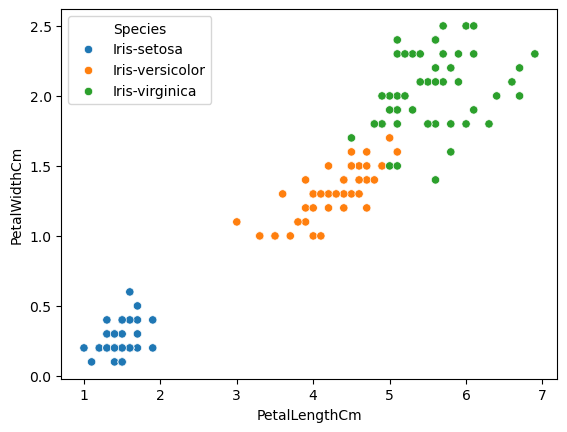

In [5]:
sns.scatterplot(data=df, x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [6]:
df = df.drop("Id", axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df["Species"].values

In [8]:
X[:5], y[:5]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2]]),
 array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
        'Iris-setosa'], dtype=object))

### Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()
y = le.fit_transform(y)
y[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [15]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([30, 4]) torch.Size([120]) torch.Size([30])


In [16]:
from torch import nn

class IrisClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.linearLayers = nn.Sequential(
            nn.Linear(in_features=4, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=3)
        )

    def forward(self, x):
        return self.linearLayers(x)

In [17]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
def calculateAccuracy(y_true, y_pred):
    return (torch.eq(y_pred, y_true).sum().item() / len(y_true)) * 100

In [19]:
model(X_test)[0:5]

tensor([[ 0.0540,  0.4185,  0.0085],
        [ 0.0912,  0.5088, -0.0445],
        [ 0.0586,  0.4237, -0.0773],
        [ 0.0650,  0.4227, -0.0769],
        [ 0.0493,  0.4331,  0.0161]], grad_fn=<SliceBackward0>)

In [20]:
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim=1)

In [21]:
y_pred_probs

tensor([[0.2945, 0.4241, 0.2814],
        [0.2949, 0.4477, 0.2574],
        [0.3018, 0.4348, 0.2635],
        [0.3033, 0.4336, 0.2631],
        [0.2911, 0.4273, 0.2816],
        [0.2864, 0.4651, 0.2485],
        [0.2855, 0.4315, 0.2830],
        [0.2864, 0.4421, 0.2716],
        [0.2935, 0.4507, 0.2558],
        [0.2942, 0.4428, 0.2630],
        [0.2762, 0.4862, 0.2377],
        [0.2946, 0.4524, 0.2529],
        [0.2924, 0.4560, 0.2516],
        [0.2865, 0.4680, 0.2455],
        [0.2871, 0.4370, 0.2760],
        [0.2892, 0.4341, 0.2767],
        [0.2783, 0.4484, 0.2732],
        [0.2964, 0.4476, 0.2560],
        [0.2906, 0.4568, 0.2526],
        [0.2955, 0.4457, 0.2587],
        [0.2821, 0.4445, 0.2734],
        [0.2957, 0.4479, 0.2564],
        [0.2856, 0.4710, 0.2434],
        [0.2863, 0.4648, 0.2489],
        [0.2957, 0.4487, 0.2556],
        [0.2883, 0.4633, 0.2484],
        [0.2875, 0.4701, 0.2424],
        [0.2806, 0.4487, 0.2707],
        [0.2886, 0.4619, 0.2495],
        [0.287

In [22]:
epochs = 150

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    
    model.train()
    
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = calculateAccuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = calculateAccuracy(y_test, test_pred)

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 25 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 1.1391 | Train Acc: 33.33% | Test Loss: 1.1096 | Test Acc: 33.33%
Epoch: 25 | Train Loss: 0.4756 | Train Acc: 91.67% | Test Loss: 0.4482 | Test Acc: 96.67%
Epoch: 50 | Train Loss: 0.1215 | Train Acc: 97.50% | Test Loss: 0.1324 | Test Acc: 96.67%
Epoch: 75 | Train Loss: 0.0667 | Train Acc: 98.33% | Test Loss: 0.0776 | Test Acc: 96.67%
Epoch: 100 | Train Loss: 0.0571 | Train Acc: 98.33% | Test Loss: 0.0599 | Test Acc: 96.67%
Epoch: 125 | Train Loss: 0.0529 | Train Acc: 98.33% | Test Loss: 0.0511 | Test Acc: 100.00%


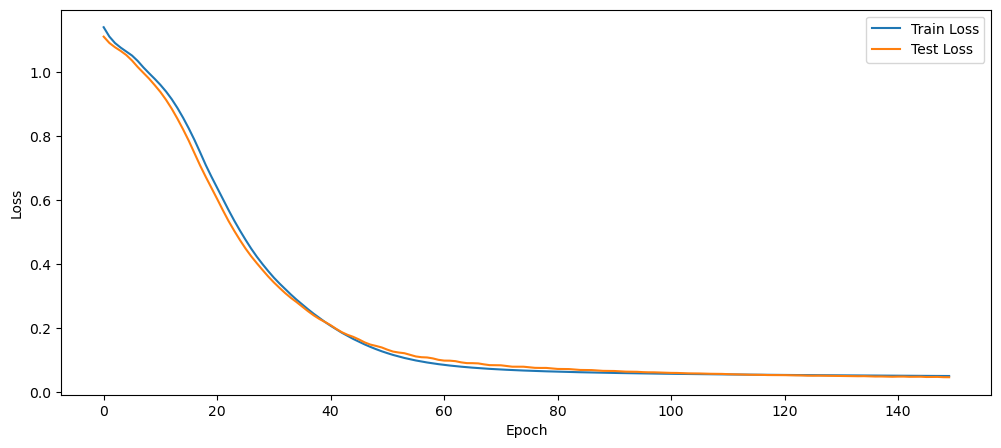

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

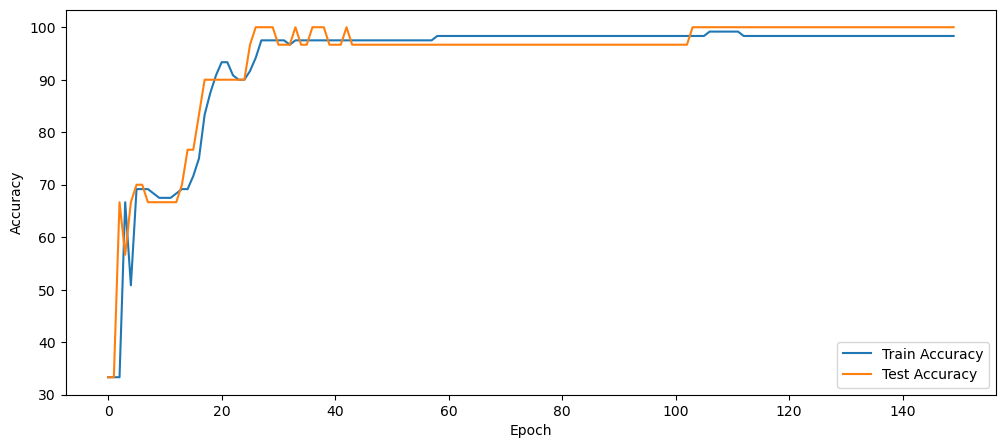

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

In [26]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [27]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = probs.argmax(dim=1)

le.inverse_transform([predicted_class])[0]

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


'Iris-setosa'

### TorchMetrics

In [28]:
%pip install torchmetrics

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [29]:
from torchmetrics.classification import MulticlassAccuracy

In [30]:
accuracy = MulticlassAccuracy(num_classes=3)

In [31]:
epoch = 250
secondModel = IrisClassifier()
loss.fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(secondModel.parameters(), lr=0.005)

for epoch in range(epoch):

    secondModel.train()
    logits = secondModel(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = accuracy(pred, y_train) * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    secondModel.eval()
    with torch.inference_mode():

        test_logits = secondModel(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred, y_test) * 100

        if epoch % 25 == 0:
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 1.3977 | Train Acc: 33.33% | Test Loss: 1.3269 | Test Acc: 33.33%
Epoch: 25 | Train Loss: 0.9517 | Train Acc: 70.83% | Test Loss: 0.9431 | Test Acc: 70.00%
Epoch: 50 | Train Loss: 0.5990 | Train Acc: 86.67% | Test Loss: 0.5827 | Test Acc: 86.67%
Epoch: 75 | Train Loss: 0.3229 | Train Acc: 96.67% | Test Loss: 0.3184 | Test Acc: 100.00%
Epoch: 100 | Train Loss: 0.1546 | Train Acc: 97.50% | Test Loss: 0.1573 | Test Acc: 100.00%
Epoch: 125 | Train Loss: 0.0934 | Train Acc: 98.33% | Test Loss: 0.0960 | Test Acc: 100.00%
Epoch: 150 | Train Loss: 0.0741 | Train Acc: 98.33% | Test Loss: 0.0735 | Test Acc: 100.00%
Epoch: 175 | Train Loss: 0.0659 | Train Acc: 97.50% | Test Loss: 0.0624 | Test Acc: 100.00%
Epoch: 200 | Train Loss: 0.0613 | Train Acc: 98.33% | Test Loss: 0.0556 | Test Acc: 100.00%
Epoch: 225 | Train Loss: 0.0583 | Train Acc: 98.33% | Test Loss: 0.0513 | Test Acc: 100.00%


In [32]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [33]:
cm = MulticlassConfusionMatrix(num_classes=3)

In [34]:
matrix = cm(test_pred, y_test)

In [35]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


In [36]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

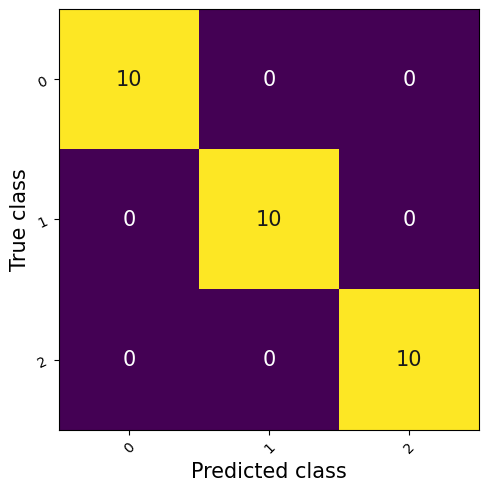

In [37]:
plot_confusion_matrix(matrix)

In [38]:
from pathlib import Path

In [39]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [40]:
MODEL_NAME = "iris_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

In [42]:
secondModel.state_dict()

OrderedDict([('linearLayers.0.weight',
              tensor([[ 0.4560,  0.3542,  0.2264, -0.5315],
                      [ 0.1361,  0.4494,  0.1296, -0.5491],
                      [ 0.4509,  0.9133, -0.8984, -0.3266],
                      [ 0.2863, -0.2081,  0.5701,  0.1727],
                      [ 0.1490, -0.3479, -0.3079, -0.2206],
                      [-0.1355, -0.2767,  0.0147, -0.1080],
                      [ 0.1854, -0.1588, -0.2445, -0.1239],
                      [-0.4854, -0.1278,  0.7116,  1.2716],
                      [-0.0242, -0.2045,  0.7717,  0.6770],
                      [ 0.4442, -0.6795,  0.7688,  0.0035]])),
             ('linearLayers.0.bias',
              tensor([ 0.4768,  0.5858,  0.7116, -0.4102,  0.2089, -0.3184, -0.2375, -1.0151,
                      -0.4968,  0.3876])),
             ('linearLayers.2.weight',
              tensor([[ 0.1525,  0.2889,  0.5931,  0.1635, -0.1453,  0.1890,  0.1024, -0.9733,
                       -0.1967,  0.0455],
        

In [43]:
torch.save(obj=secondModel.state_dict(), f=MODEL_SAVE_PATH)

In [44]:
loadedModel = IrisClassifier()
loadedModel.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [45]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

In [46]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [48]:
loadedModel.eval()
with torch.inference_mode():
    logits = loadedModel(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = probs.argmax(dim=1)

le.inverse_transform([predicted_class])[0]

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


'Iris-setosa'